In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos (usaremos archivo de ejemplo ventas.csv)
df = pd.read_csv('ventas.csv')

# Exploración inicial
print(df.head())
print(df.info())
print(df.describe())


        fecha    categoria          producto  cantidad  precio_unitario  \
0  2025-01-15  Electronica         Laptop HP         2            850.0   
1  2025-01-15  Electronica    Mouse Logitech         5             25.0   
2  2025-01-16   Accesorios  Auriculares Sony         3            120.0   
3  2025-01-16  Electronica    Tablet Samsung         1            450.0   
4  2025-01-17  Electronica      Monitor Dell         4            320.0   

   ventas    ciudad       vendedor    metodo_pago  
0  1700.0  San Jose     Juan Perez        Tarjeta  
1   125.0  San Jose     Juan Perez       Efectivo  
2   360.0   Cartago    Maria Lopez        Tarjeta  
3   450.0   Heredia    Carlos Mora  Transferencia  
4  1280.0  Alajuela  Ana Rodriguez        Tarjeta  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha            30 non-null     objec

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos (usaremos archivo de ejemplo ventas.csv)
df = pd.read_csv('clientes.csv')

# Exploración inicial
print(df.head())
print(df.info())
print(df.describe())

   cliente_id            nombre                       email fecha_registro  \
0           1    Juan Hernández    juan.hernández@email.com     2025-06-30   
1           2      juan ramírez      juan.ramírez@email.com     2024-10-31   
2           3  CARMEN RODRÍGUEZ  carmen.rodríguez@email.com     2024-08-02   
3           4     CARMEN TORRES     carmen.torres@email.com     2024-06-12   
4           5    Luis Rodríguez    luis.rodríguez@email.com     2024-09-11   

           ciudad segmento fuente_adquisicion  
0        San José      NaN           Facebook  
1    Guanacaste     Básico           Referido  
2      Puntarenas  Premium    Email Marketing  
3      Guanacaste   Básico         Google Ads  
4           Limón   Básico           Facebook  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   cliente_id          5000 non-null   

# Task
The task is to identify and count duplicate records in the `df_clientes` DataFrame, which was loaded from "clientes.csv". The duplicates should be identified based on all columns or specific columns like 'email', 'nombre', and 'fecha_registro'. Finally, display the duplicate records and their count, then summarize the findings and ask the user for further actions.

## Cargar Datos de Clientes

### Subtask:
Asegurar que el DataFrame `df_clientes` está cargado con los datos del archivo `clientes.csv`.


## Identificar Duplicados

### Subtask:
Detectar registros duplicados en el DataFrame `df_clientes`.


**Reasoning**:
The subtask requires identifying duplicate records in `df_clientes` based on all columns and then based on a specific subset of columns. The `duplicated()` method with `keep=False` is suitable for this, followed by displaying the head and shape of the resulting dataframes as requested.



In [17]:
print('Paso 1: Identificación de duplicados en todas las columnas')
duplicados_todas_columnas = df_clientes[df_clientes.duplicated(keep=False)]
print('Primeras 5 filas de duplicados_todas_columnas:')
print(duplicados_todas_columnas.head())
print(f'Cantidad de filas y columnas de duplicados_todas_columnas: {duplicados_todas_columnas.shape}')

print('\nPaso 2: Identificación de duplicados en columnas críticas (email, nombre, fecha_registro)')
duplicados_columnas_criticas = df_clientes[df_clientes.duplicated(subset=['email', 'nombre', 'fecha_registro'], keep=False)]
print('Primeras 5 filas de duplicados_columnas_criticas:')
print(duplicados_columnas_criticas.head())
print(f'Cantidad de filas y columnas de duplicados_columnas_criticas: {duplicados_columnas_criticas.shape}')

Paso 1: Identificación de duplicados en todas las columnas
Primeras 5 filas de duplicados_todas_columnas:
Empty DataFrame
Columns: [cliente_id, nombre, email, fecha_registro, ciudad, segmento, fuente_adquisicion]
Index: []
Cantidad de filas y columnas de duplicados_todas_columnas: (0, 7)

Paso 2: Identificación de duplicados en columnas críticas (email, nombre, fecha_registro)
Primeras 5 filas de duplicados_columnas_criticas:
     cliente_id         nombre                    email fecha_registro  \
47           48  Ana Hernández  ana.hernández@email.com     2023-02-03   
48           49   ana gonzález   ana.gonzález@email.com     2025-01-11   
108         109     Luis López     luis.lópez@email.com     2023-02-10   
196         197     José Pérez     josé.pérez@email.com     2025-07-19   
328         178  José Martínez  josé.martínez@email.com     2023-03-01   

         ciudad segmento fuente_adquisicion  
47   Puntarenas   Básico           Referido  
48      Heredia   Básico         

In [18]:
print('1. Confirmación de duplicados en todas las columnas:')
if duplicados_todas_columnas.shape[0] == 0:
    print('No se encontraron registros duplicados idénticos en todas las columnas.')
else:
    print(f'Se encontraron {duplicados_todas_columnas.shape[0]} registros duplicados idénticos en todas las columnas.')

print('\n2. Primeras 5 filas de duplicados en columnas críticas (email, nombre, fecha_registro):')
print(duplicados_columnas_criticas.head())

print(f'\n3. Número total de filas que son parte de un grupo de duplicados en columnas críticas: {duplicados_columnas_criticas.shape[0]}')

# Instruction 4: Calculate the number of unique combinations of ('email', 'nombre', 'fecha_registro') that appear more than once.
critical_columns = ['email', 'nombre', 'fecha_registro']
grouped = df_clientes.groupby(critical_columns).size().reset_index(name='count')
num_unique_combinations_with_duplicates = grouped[grouped['count'] > 1].shape[0]
print(f'\n4. Cantidad de combinaciones únicas ({', '.join(critical_columns)}) que aparecen más de una vez: {num_unique_combinations_with_duplicates}')

1. Confirmación de duplicados en todas las columnas:
No se encontraron registros duplicados idénticos en todas las columnas.

2. Primeras 5 filas de duplicados en columnas críticas (email, nombre, fecha_registro):
     cliente_id         nombre                    email fecha_registro  \
47           48  Ana Hernández  ana.hernández@email.com     2023-02-03   
48           49   ana gonzález   ana.gonzález@email.com     2025-01-11   
108         109     Luis López     luis.lópez@email.com     2023-02-10   
196         197     José Pérez     josé.pérez@email.com     2025-07-19   
328         178  José Martínez  josé.martínez@email.com     2023-03-01   

         ciudad segmento fuente_adquisicion  
47   Puntarenas   Básico           Referido  
48      Heredia   Básico           Facebook  
108     Cartago      NaN           Orgánico  
196       Limón      VIP           Referido  
328    San José  Premium           Referido  

3. Número total de filas que son parte de un grupo de duplicados

Valores faltantes por columna en df (clientes):
cliente_id              0
nombre                  0
email                 631
fecha_registro          0
ciudad                372
segmento              721
fuente_adquisicion      0
dtype: int64

Número de registros duplicados en df (clientes): 0


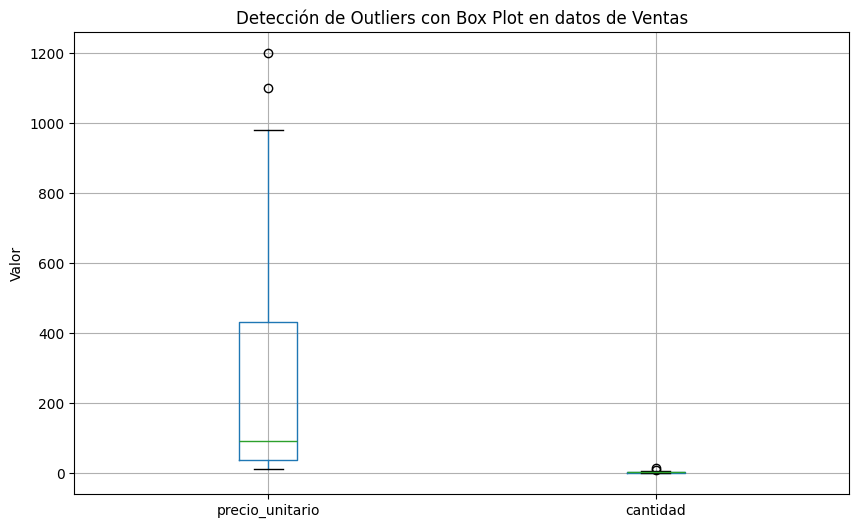

In [19]:
import matplotlib.pyplot as plt

# Valores faltantes en df (clientes)
print('Valores faltantes por columna en df (clientes):')
print(df.isnull().sum())

# Duplicados en df (clientes)
print(f"\nNúmero de registros duplicados en df (clientes): {df.duplicated().sum()}")

# Cargar df_ventas para el análisis de outliers, ya que 'precio_unitario' y 'cantidad' están en ventas.csv
df_ventas = pd.read_csv('ventas.csv')

# Outliers con box plot en df_ventas
plt.figure(figsize=(10, 6))
df_ventas.boxplot(column=['precio_unitario', 'cantidad'])
plt.title('Detección de Outliers con Box Plot en datos de Ventas')
plt.ylabel('Valor')
plt.show()

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que 'fecha' sea un tipo de dato datetime
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

# Extraer componentes temporales
df_ventas['dia_semana'] = df_ventas['fecha'].dt.day_name() # Nombre del día de la semana
df_ventas['mes'] = df_ventas['fecha'].dt.month_name() # Nombre del mes
df_ventas['anio'] = df_ventas['fecha'].dt.year # Año
df_ventas['dia_del_mes'] = df_ventas['fecha'].dt.day # Día del mes

print("DataFrame de ventas con componentes temporales añadidos (primeras 5 filas):")
display(df_ventas.head())

DataFrame de ventas con componentes temporales añadidos (primeras 5 filas):


,fecha,categoria,producto,cantidad,precio_unitario,ventas,ciudad,vendedor,metodo_pago,dia_semana,mes,anio,dia_del_mes
0,2025-01-15,Electronica,Laptop HP,2,850.0,1700.0,San Jose,Juan Perez,Tarjeta,Wednesday,January,2025,15
1,2025-01-15,Electronica,Mouse Logitech,5,25.0,125.0,San Jose,Juan Perez,Efectivo,Wednesday,January,2025,15
2,2025-01-16,Accesorios,Auriculares Sony,3,120.0,360.0,Cartago,Maria Lopez,Tarjeta,Thursday,January,2025,16
3,2025-01-16,Electronica,Tablet Samsung,1,450.0,450.0,Heredia,Carlos Mora,Transferencia,Thursday,January,2025,16
4,2025-01-17,Electronica,Monitor Dell,4,320.0,1280.0,Alajuela,Ana Rodriguez,Tarjeta,Friday,January,2025,17


### Patrones de Venta Diarios (por día de la semana)

/tmp/ipython-input-3519737748.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')


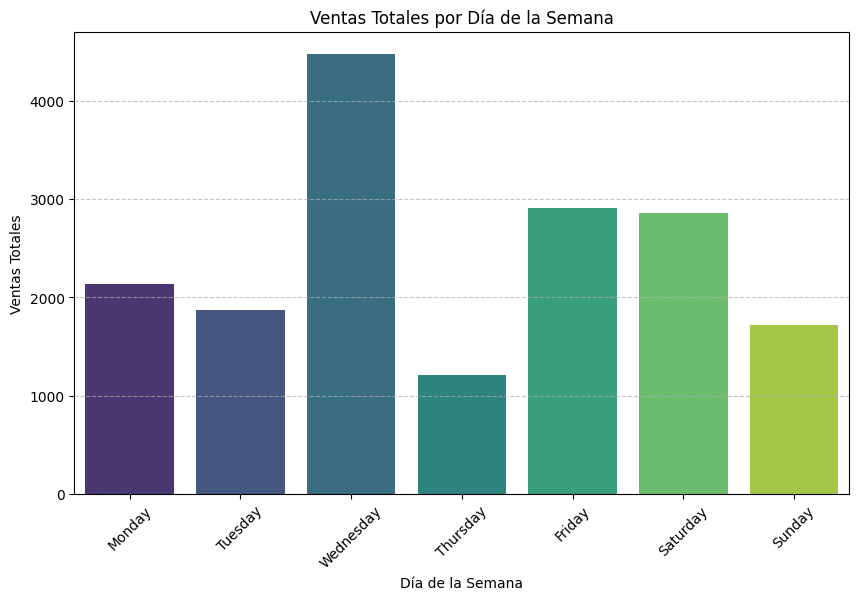

In [21]:
# Agrupar ventas por día de la semana
ventas_por_dia_semana = df_ventas.groupby('dia_semana')['ventas'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
]).fillna(0)

plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')
plt.title('Ventas Totales por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Patrones de Venta Mensuales

/tmp/ipython-input-64714871.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_mes.index, y=ventas_por_mes.values, palette='magma')


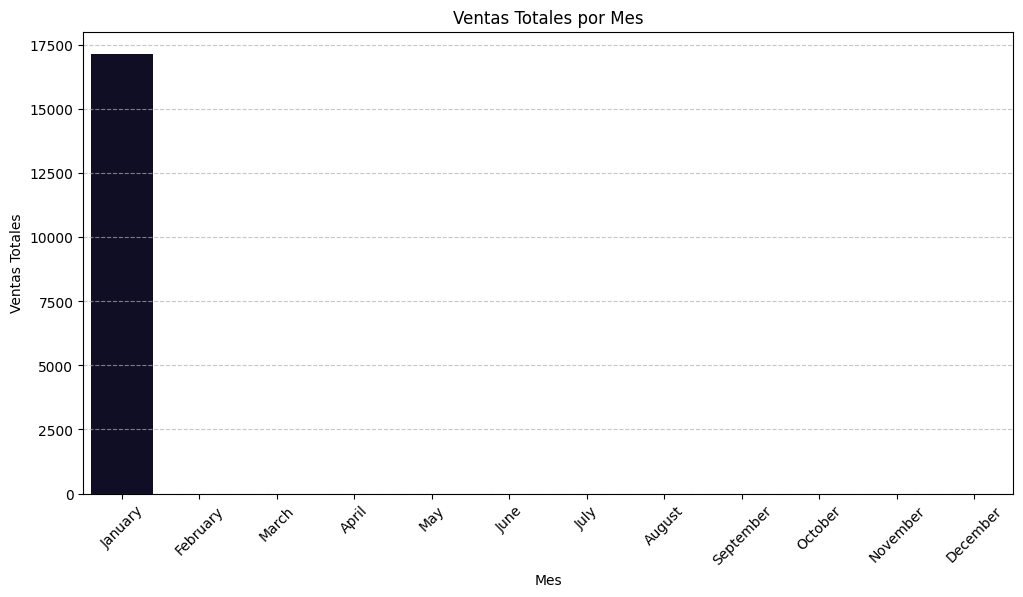

In [22]:
# Agrupar ventas por mes
ventas_por_mes = df_ventas.groupby('mes')['ventas'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'
]).fillna(0)

plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_por_mes.index, y=ventas_por_mes.values, palette='magma')
plt.title('Ventas Totales por Mes')
plt.xlabel('Mes')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Patrones de Venta por Día del Mes

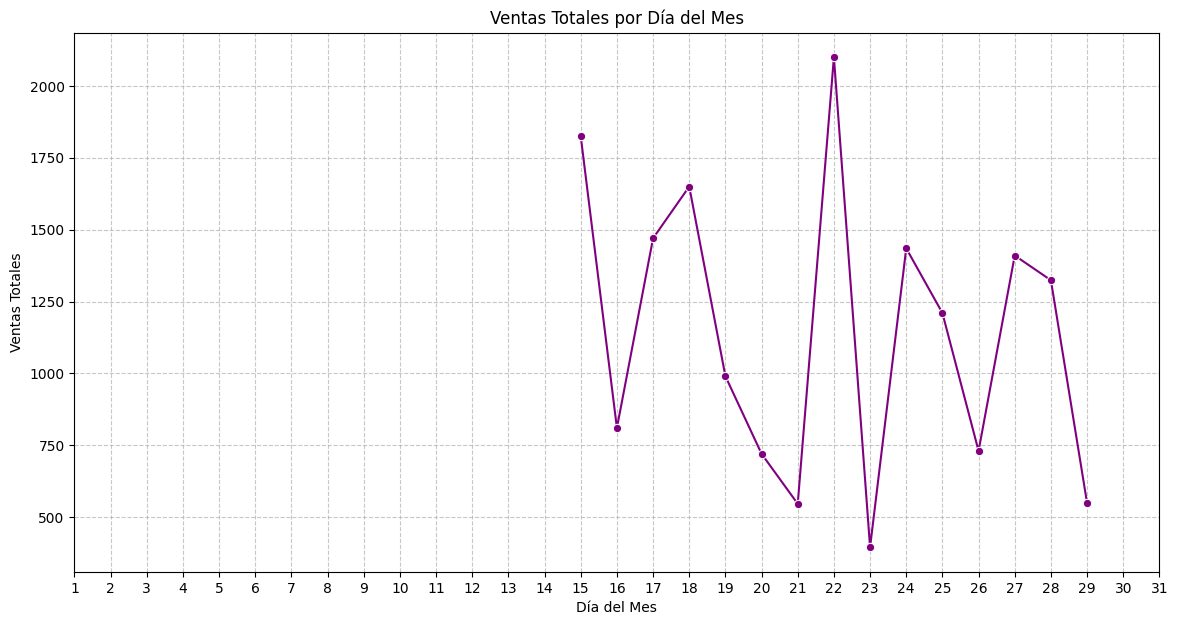

In [23]:
# Agrupar ventas por día del mes
ventas_por_dia_del_mes = df_ventas.groupby('dia_del_mes')['ventas'].sum()

plt.figure(figsize=(14, 7))
sns.lineplot(x=ventas_por_dia_del_mes.index, y=ventas_por_dia_del_mes.values, marker='o', color='purple')
plt.title('Ventas Totales por Día del Mes')
plt.xlabel('Día del Mes')
plt.ylabel('Ventas Totales')
plt.xticks(range(1, 32)) # Mostrar todos los días del mes
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

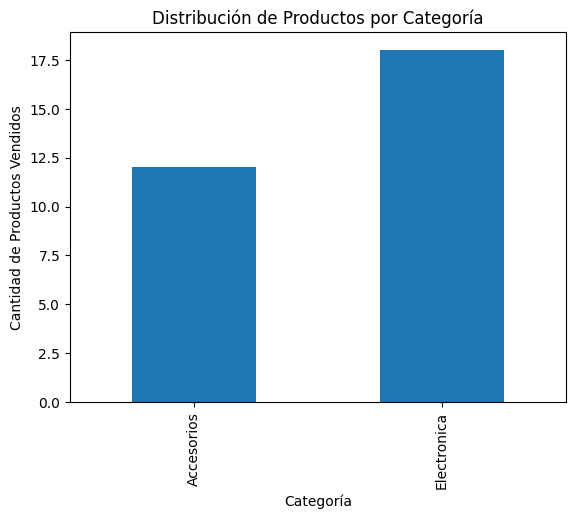

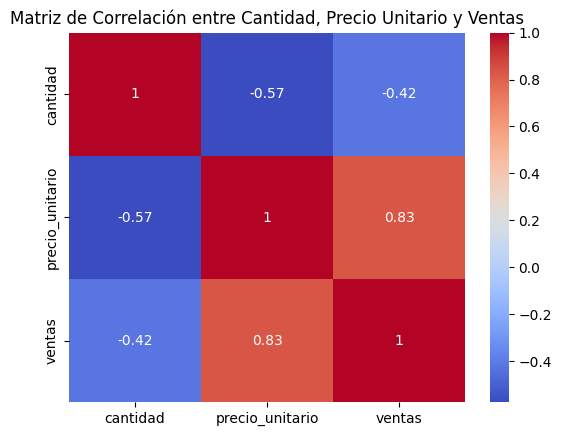

In [25]:
# Distribución de productos por categoría
df_ventas.groupby('categoria')['producto'].count().plot(kind='bar')
plt.title('Distribución de Productos por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de Productos Vendidos')
plt.show()

# Correlación entre variables numéricas
correlation = df_ventas[['cantidad', 'precio_unitario', 'ventas']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Cantidad, Precio Unitario y Ventas')
plt.show()